In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!unzip "/content/drive/MyDrive/EVSE.zip" -d /content/drive/MyDrive/

In [ ]:
import pandas as pd

df_net = pd.read_csv(
    "/content/drive/MyDrive/EVSE/Network Traffic/EVSE-A/csv/EVSE-A-charging-Aggressive-scan.csv"
)

print(df_net.shape)
print(df_net.columns)
df_net.head()

In [ ]:
df_host = pd.read_csv(
    "/content/drive/MyDrive/EVSE/Host Events/EVSE-B-HPC-Kernel-Events-Combined.csv"
)

print(df_host.shape)
print(df_host.columns)
df_host.head()

In [ ]:
df_power = pd.read_csv(
    "/content/drive/MyDrive/EVSE/Power Consumption/EVSE-B-PowerCombined.csv"
)

print(df_power.shape)
print(df_power.columns)
df_power.head()

In [9]:
import math
import io
import shutil
import os
import sys
from os import path
import json

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/EVSE/Host Events/EVSE-B-HPC-Kernel-Events-Combined.csv", low_memory=False
)
df

In [ ]:
print(df_host['writeback_writeback_written'].unique())
print(df_host['State'].unique())
print(df_host['Attack'].unique())
print(df_host['Scenario'].unique())
print(df_host['Label'].unique())

In [ ]:
corrupted_df = df_host[df_host['State'] == '0']
corrupted_df[:5]

In [ ]:
fixed_df = corrupted_df.copy(deep=True)

fixed_df['State'] = fixed_df['interface']
fixed_df['Attack'] = fixed_df['Unnamed: 911']
fixed_df['Scenario'] = fixed_df['Unnamed: 912']
fixed_df['Label'] = fixed_df['Unnamed: 913']
fixed_df['interface'] = fixed_df['Unnamed: 914']
fixed_df[:5]

In [ ]:
valid_df = df_host[df_host['State'].isin(['Charging', 'idle'])]
combined_df = pd.concat([valid_df, fixed_df], axis=0, ignore_index=True)
combined_df = combined_df.drop(columns=['Unnamed: 911', 'Unnamed: 912', 'Unnamed: 913', 'Unnamed: 914'])

combined_df

In [ ]:
combined_df.shape

In [ ]:
combined_df['isDoS'] = combined_df['Scenario']=='DoS'
combined_df

In [ ]:
cleaned_na = combined_df.dropna()
cleaned_na.shape

In [ ]:
column_types = set()
for col in cleaned_na.columns:
    column_types.add(pd.api.types.infer_dtype(cleaned_na[col]))
column_types

In [19]:
import os
os.makedirs('dataset', exist_ok=True)
cleaned_na.to_csv(os.path.join('dataset', 'EVSE-B-HPC-Kernel-Events-cleaned.csv'), index=False)

In [ ]:
df = pd.read_csv(path.join('dataset', 'EVSE-B-HPC-Kernel-Events-cleaned.csv'))
df

In [ ]:
numerical_columns = []
string_columns = []
for col in df.columns:
    if pd.api.types.infer_dtype(df[col]) != 'string':
        numerical_columns.append(col)
    else:
        string_columns.append(col)

numerical_df = df[numerical_columns]
numerical_df

catergorical_df = df[string_columns].copy(deep=True)
catergorical_df = pd.get_dummies(catergorical_df, columns=string_columns)
catergorical_df

In [ ]:
# Define the label column
label_column = 'isDoS'

# Calculate correlation of all other columns with the label column
correlation = numerical_df.corr()[label_column]

# Drop the label itself (correlation of label with itself is 1)
correlation = correlation.drop(label_column)

# Sort by the absolute value of the correlation in descending order
top_features = correlation.abs().sort_values(ascending=False).head(10)

# Get the column names of the top features
top_columns = top_features.index.tolist()
top_columns

In [ ]:
top_numerical_df = numerical_df[top_columns]
top_numerical_df

In [ ]:
label_df = numerical_df['isDoS']

processed_df = pd.concat([top_numerical_df, catergorical_df, label_df], axis=1)
processed_df

In [25]:
processed_df.to_csv(path.join('dataset', 'EVSE-B-HPC-Kernel-Events-processed.csv'), index=False)

In [ ]:
df = pd.read_csv(path.join('dataset', 'EVSE-B-HPC-Kernel-Events-processed.csv'))
df

In [ ]:
# min-max normalization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(df)
df_normalized = pd.DataFrame(normalized_data, columns=df.columns)
df_normalized

In [28]:
# data splitting: training and testing
from sklearn.model_selection import train_test_split

# Separate features and labels
# X = df_normalized.iloc[:, :-1].values  # All columns except the last one
X = df_normalized.iloc[:, :10].values  # All columns except the last one
y = df_normalized.iloc[:, -1].values   # The last column (label)

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device).unsqueeze(1)

# If the labels are for classification, ensure they're of `long` dtype
# y_train_tensor = y_train_tensor.long()
# y_test_tensor = y_test_tensor.long()

In [ ]:
print(X_train_tensor.shape)
print(X_test_tensor.shape)
print(y_train_tensor.shape)
print(y_test_tensor.shape)

In [40]:
import torch.nn as nn

# define model, loss function, optimizer
class TransformerBinaryClassifier(nn.Module):
    def __init__(self, d_model, nhead, num_layers):
        super(TransformerBinaryClassifier, self).__init__()

        # Transformer Encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            activation='relu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Fully connected layers for binary classification
        self.fc = nn.Sequential(
            nn.Linear(d_model, d_model // 2),  # Reduce to half
            nn.ReLU(),
            nn.Linear(d_model // 2, 1),        # Output 1 value for binary classification
            nn.Sigmoid()                      # Sigmoid for binary classification
        )

    def forward(self, x):
        """
        x: Input tensor of shape (batch_size, seq_len, d_model)
           For a series of length 1, seq_len=1.
        """
        # Ensure input has shape (seq_len, batch_size, d_model) for Transformer
        x = x.permute(1, 0, 2)

        # Transformer Encoder
        encoded = self.transformer_encoder(x)  # Shape: (seq_len, batch_size, d_model)

        # For a single timestep, seq_len=1, so take the output directly
        cls_token_embedding = encoded[0]  # Shape: (batch_size, d_model)

        # Pass through the classification head
        output = self.fc(cls_token_embedding)  # Shape: (batch_size, 1)

        return output

# # Define model parameters
# d_model = 41
# nhead = 1
# num_layers = 2

# # Create model instance
# model = TransformerBinaryClassifier(d_model, nhead, num_layers)

# # Dummy input: (batch_size=16, seq_len=1, d_model=128)
# x = torch.rand(16, 1, d_model)

# # Forward pass
# output = model(x)
# # print(output.shape)  # Output shape: (16, 1)

# # training pipeline + evaluation + curve plotting

In [ ]:
print(combined_df['isDoS'].value_counts())

isDoS
False    6298
True      865
Name: count, dtype: int64


Epoch 1/8: Train Loss = 1.2842, Validation Loss = 1.2486
Epoch 1/8:
  Train Loss = 1.2842
  Validation Loss = 1.2486
  Validation Accuracy = 0.2820,
Epoch 2/8: Train Loss = 1.2589, Validation Loss = 1.2254
Epoch 2/8:
  Train Loss = 1.2589
  Validation Loss = 1.2254
  Validation Accuracy = 0.4344,
Epoch 3/8: Train Loss = 1.2389, Validation Loss = 1.2062
Epoch 3/8:
  Train Loss = 1.2389
  Validation Loss = 1.2062
  Validation Accuracy = 0.6953,
Epoch 4/8: Train Loss = 1.2249, Validation Loss = 1.1919
Epoch 4/8:
  Train Loss = 1.2249
  Validation Loss = 1.1919
  Validation Accuracy = 0.8833,
Epoch 5/8: Train Loss = 1.2088, Validation Loss = 1.1815
Epoch 5/8:
  Train Loss = 1.2088
  Validation Loss = 1.1815
  Validation Accuracy = 0.9173,
Epoch 6/8: Train Loss = 1.1972, Validation Loss = 1.1745
Epoch 6/8:
  Train Loss = 1.1972
  Validation Loss = 1.1745
  Validation Accuracy = 0.9384,
Epoch 7/8: Train Loss = 1.2003, Validation Loss = 1.1697
Epoch 7/8:
  Train Loss = 1.2003
  Validation Los

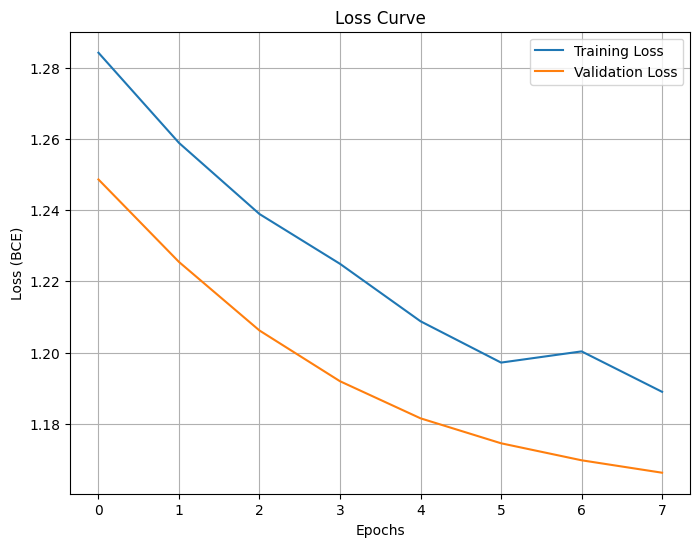

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from imblearn.over_sampling import SMOTE

# Example parameters (adjust these for your use case)
d_model = 10
nhead = 2
num_layers = 2
batch_size = 2048
epochs = 8
patience = 5  # Early stopping patience

# Define the model
model = TransformerBinaryClassifier(d_model, nhead, num_layers).to(device)

# Define loss function and optimizer
pos_weight = torch.tensor([1069/165]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Create DataLoaders for training and testing
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Training pipeline with early stopping
best_val_loss = float('inf')
epochs_no_improve = 0

# Initialize lists to store loss values
train_losses = []
val_losses = []

# Variables to store the predictions and labels of the best model
best_model_final_preds = []
best_model_final_labels = []

for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation phase
    model.eval()
    val_loss = 0.0
    current_epoch_preds = []  # Store preds for current epoch to check for best model
    current_epoch_labels = []  # Store labels for current epoch to check for best model
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

            # Convert predictions to binary (threshold = 0.5)
            preds = (outputs > 0.5).long()
            current_epoch_preds.extend(preds.cpu().numpy())
            current_epoch_labels.extend(y_batch.cpu().numpy())

    val_loss /= len(test_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs}: Train Loss = {train_loss:.4f}, Validation Loss = {val_loss:.4f}")

    # Calculate metrics
    accuracy = accuracy_score(current_epoch_labels, current_epoch_preds)
    precision = precision_score(current_epoch_labels, current_epoch_preds, zero_division=0)
    recall = recall_score(current_epoch_labels, current_epoch_preds, zero_division=0)

    print(f"Epoch {epoch+1}/{epochs}:")
    print(f"  Train Loss = {train_loss:.4f}")
    print(f"  Validation Loss = {val_loss:.4f}")
    print(f"  Validation Accuracy = {accuracy:.4f},")

    # Check for improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Save the best model
        torch.save(model.state_dict(), "best_model.pth")
        # Store predictions and labels from the best model
        best_model_final_preds = current_epoch_preds
        best_model_final_labels = current_epoch_labels
    else:
        epochs_no_improve += 1

    # Early stopping condition
    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        break

# Load the best model after training
model.load_state_dict(torch.load("best_model.pth"))
print("Training complete. Best model loaded.")

# --- Final evaluation with the best model ---
# Re-evaluate with the best model to ensure correct classification report
model.eval()
final_preds_best_model = []
final_labels_best_model = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = (outputs > 0.5).long()
        final_preds_best_model.extend(preds.cpu().numpy())
        final_labels_best_model.extend(y_batch.cpu().numpy())

# Print final classification report using predictions from the best model
print("\n--- Classification Report for the Best Model ---")
print(classification_report(final_labels_best_model, final_preds_best_model, zero_division=0))


# Plot the loss curve
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (BCE)')
plt.title('Loss Curve')
plt.legend()
plt.grid()
plt.savefig('loss_curve.png')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = np.array(final_preds_best_model)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.87      1.00      0.93      1069
         1.0       0.00      0.00      0.00       165

    accuracy                           0.87      1234
   macro avg       0.43      0.50      0.46      1234
weighted avg       0.75      0.87      0.80      1234



In [ ]:
df_processed = pd.read_csv(path.join('dataset', 'EVSE-B-HPC-Kernel-Events-processed.csv'))

print(df_processed.shape)
df_processed.head()

In [ ]:
X = df_processed.drop(columns=['isDoS'])
y = df_processed['isDoS']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Shape of features (X): (6166, 41)
Shape of target (y): (6166,)


In [ ]:
numerical_features = []
categorical_features = []

for col in X.columns:
    if col in top_columns:
        numerical_features.append(col)
    else:
        categorical_features.append(col)

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

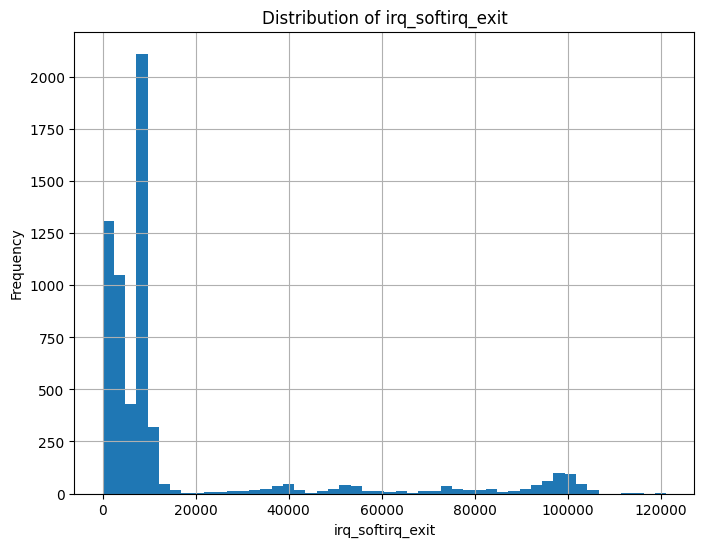

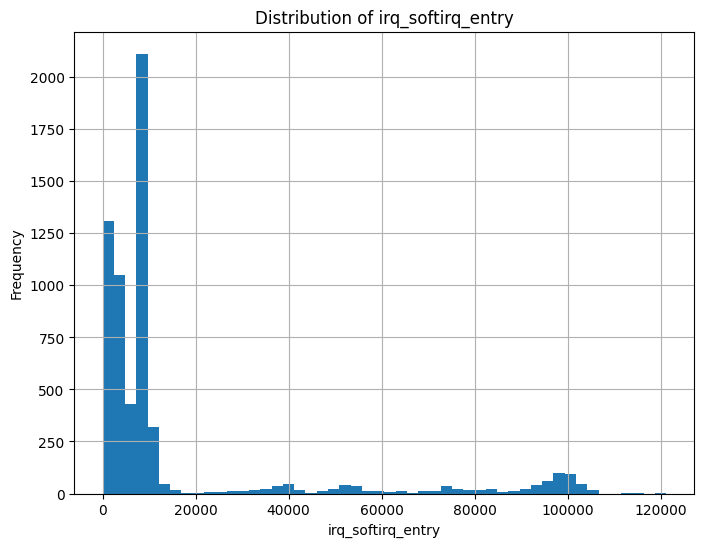

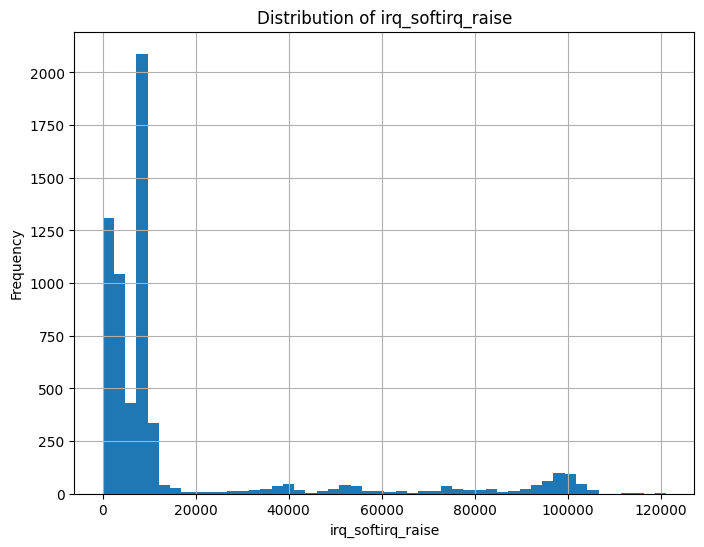

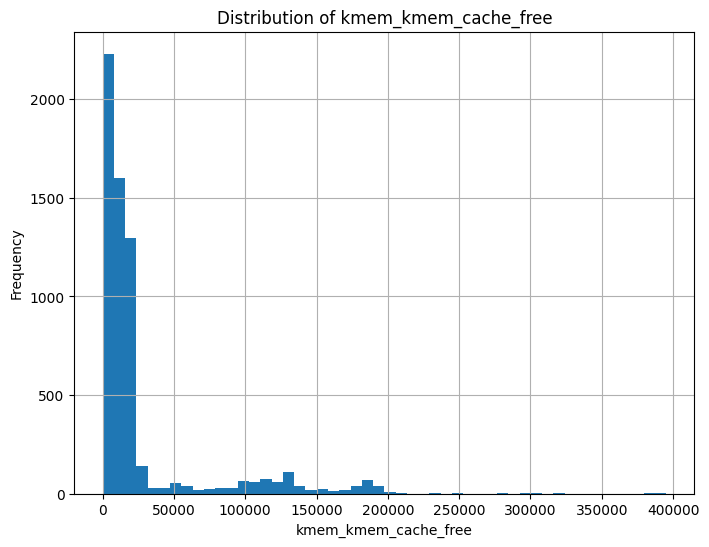

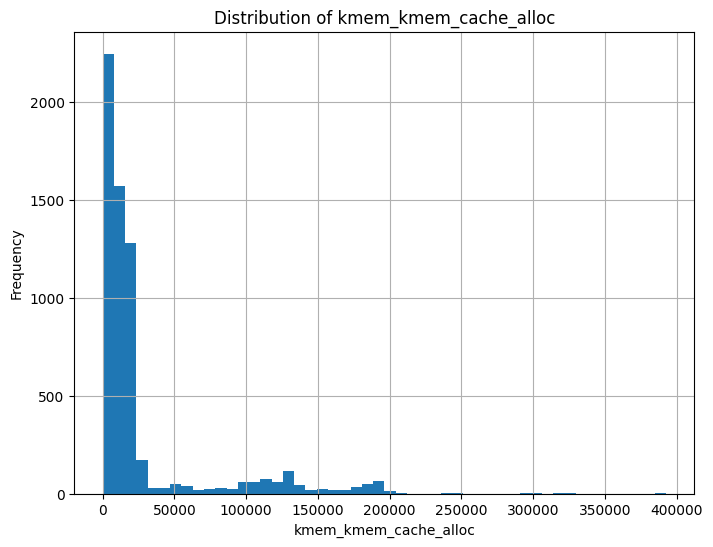

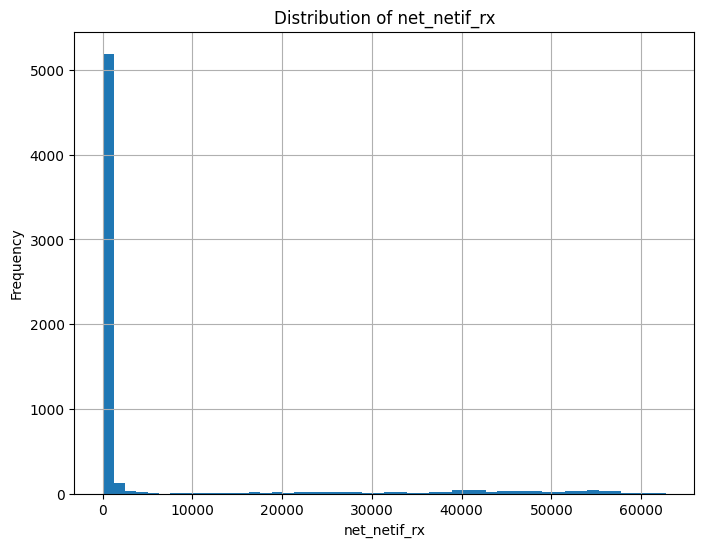

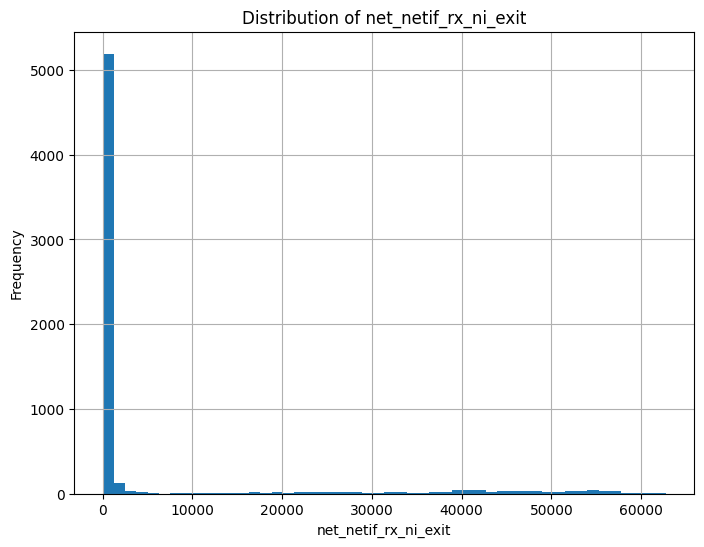

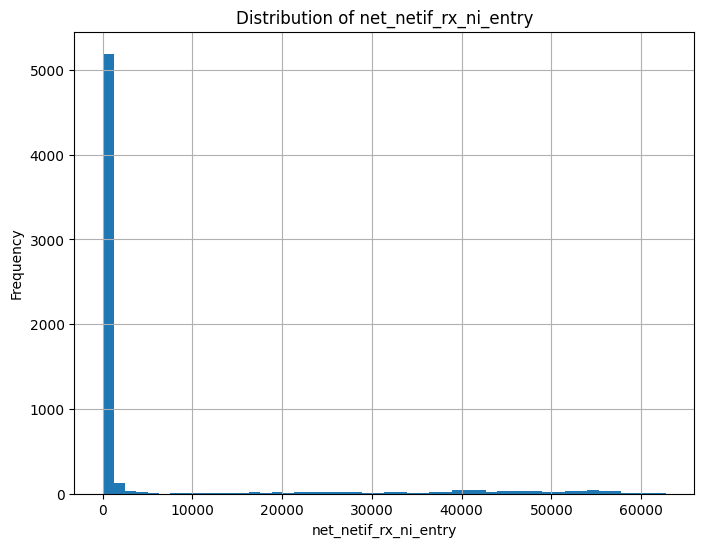

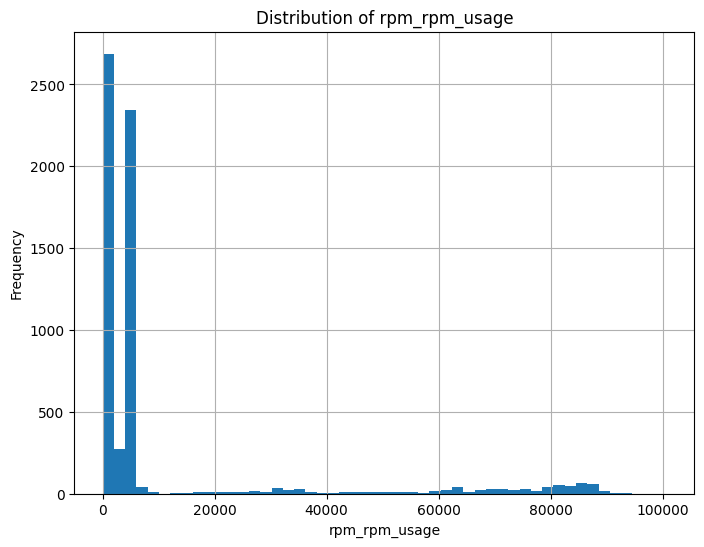

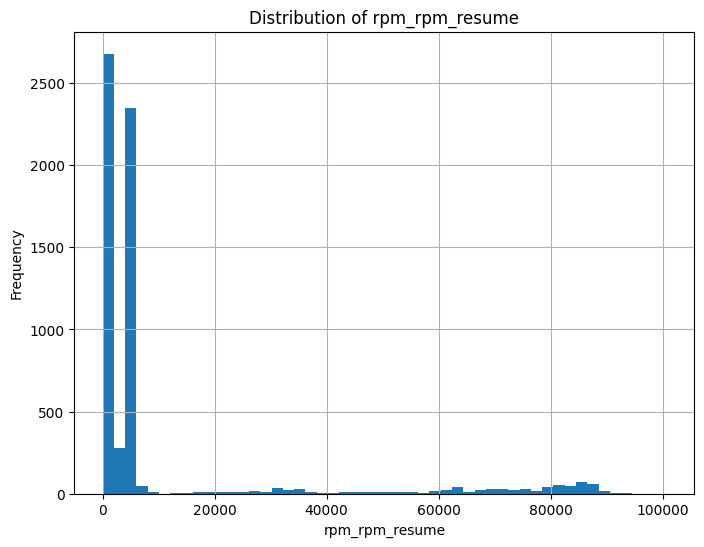

In [ ]:
for feature_name in numerical_features:
    plt.figure(figsize=(8, 6))
    X[feature_name].hist(bins=50)
    plt.title(f'Distribution of {feature_name}')
    plt.xlabel(feature_name)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

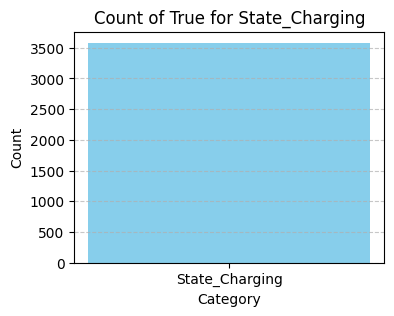

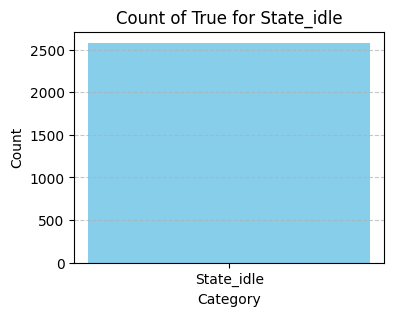

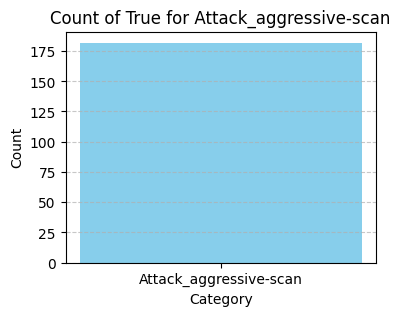

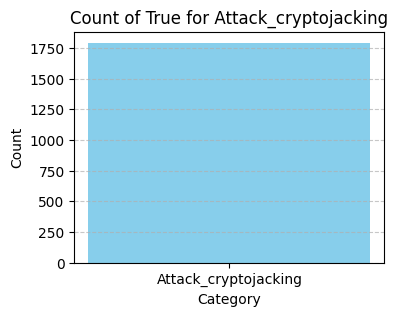

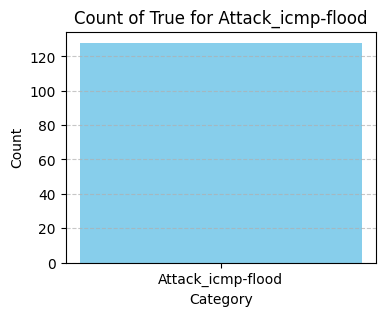

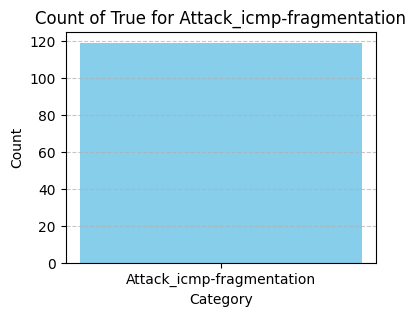

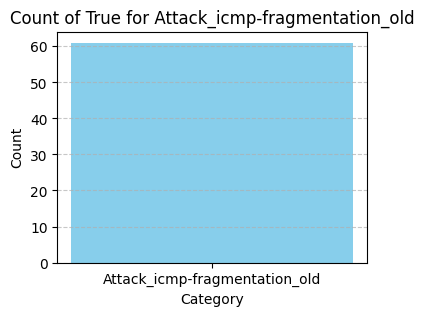

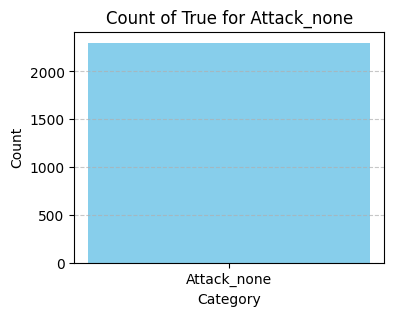

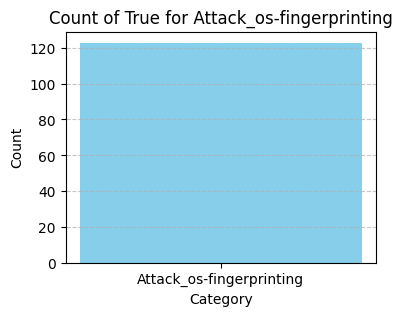

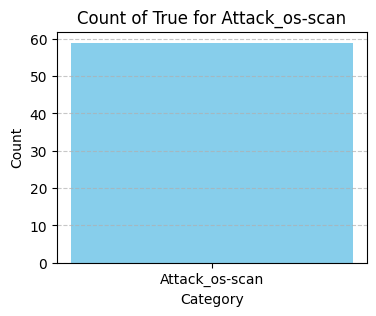

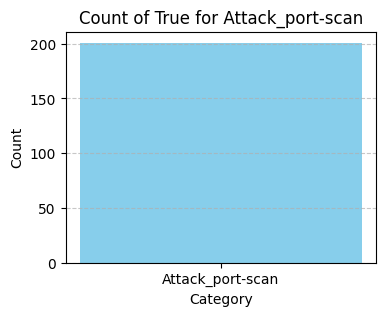

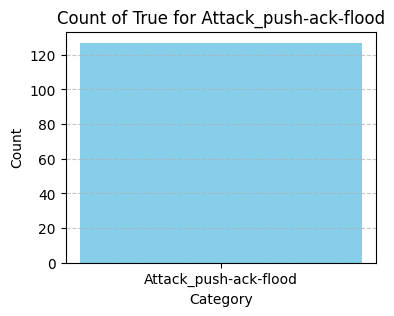

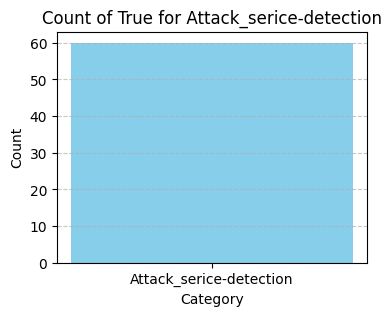

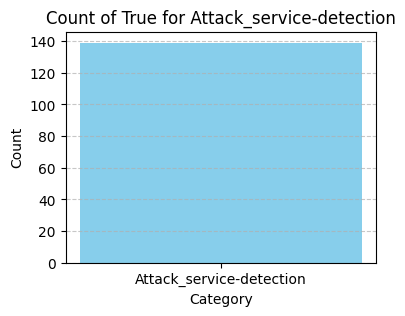

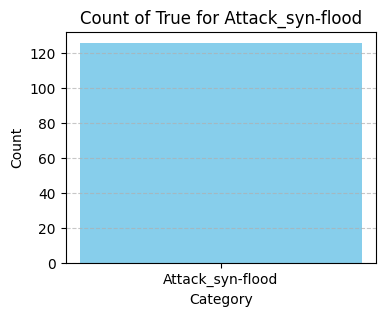

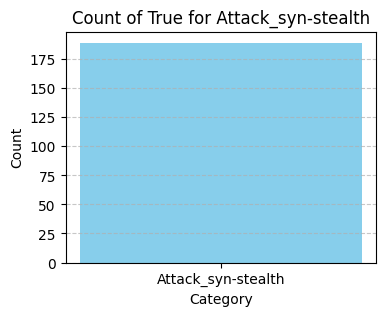

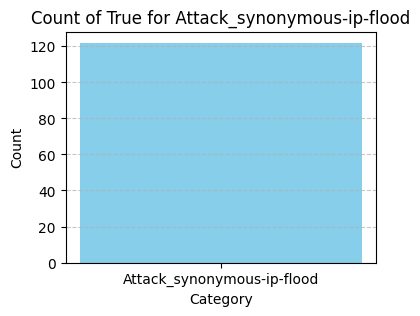

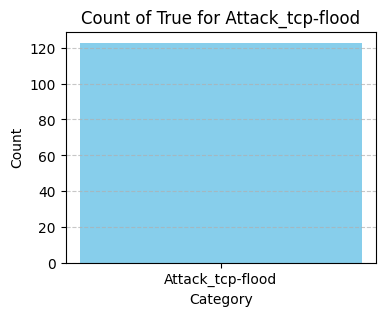

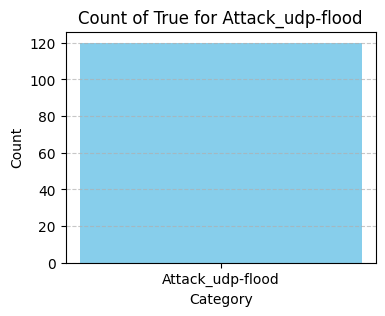

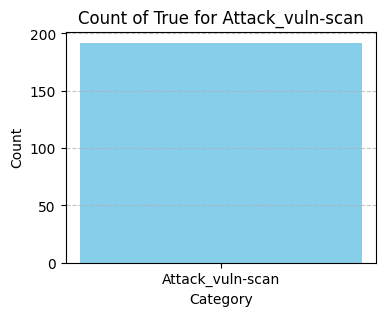

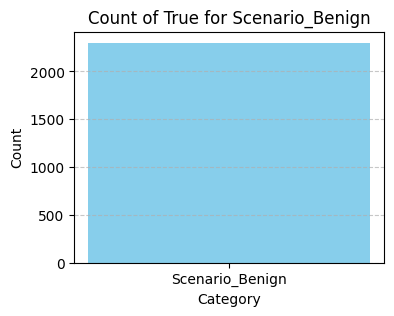

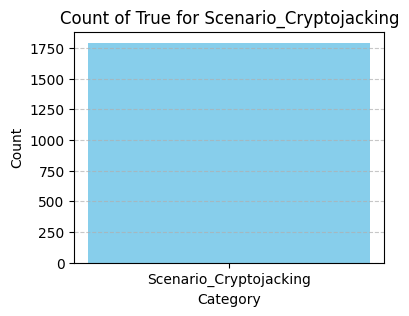

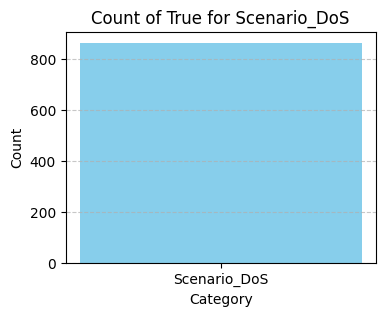

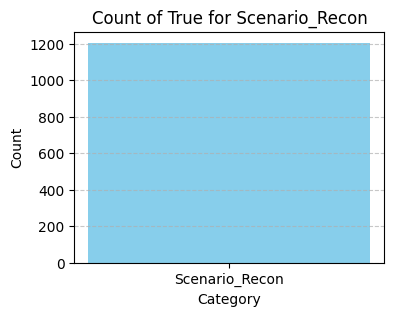

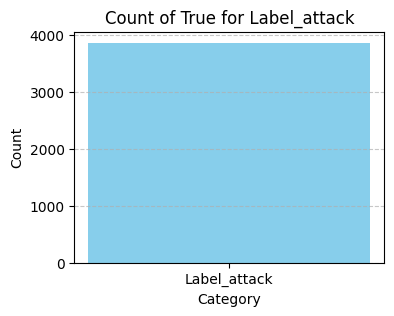

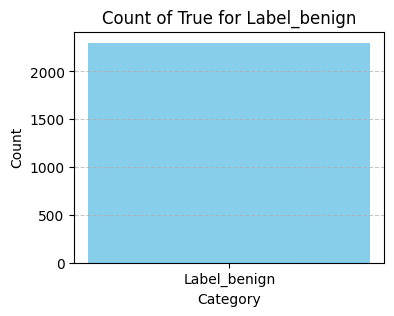

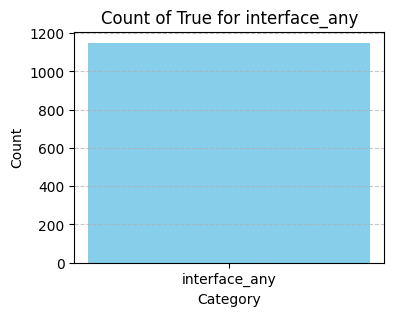

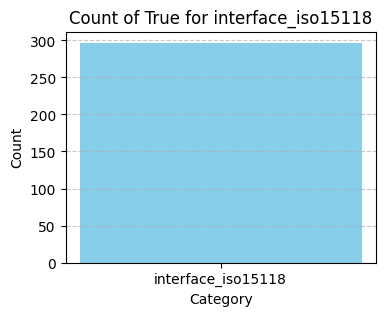

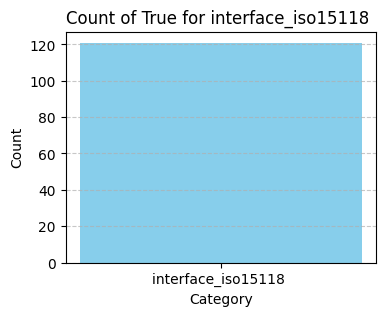

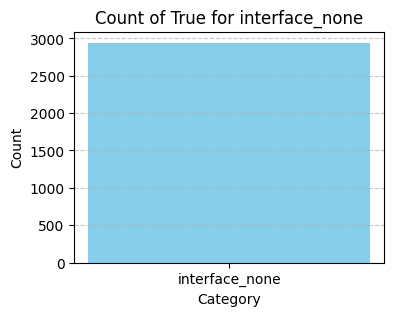

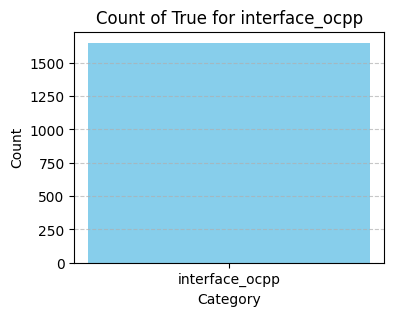

In [ ]:
for feature_name in categorical_features:
    plt.figure(figsize=(4, 3))
    true_count = X[feature_name].sum()
    plt.bar([feature_name], [true_count], color='skyblue')
    plt.title(f'Count of True for {feature_name}')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

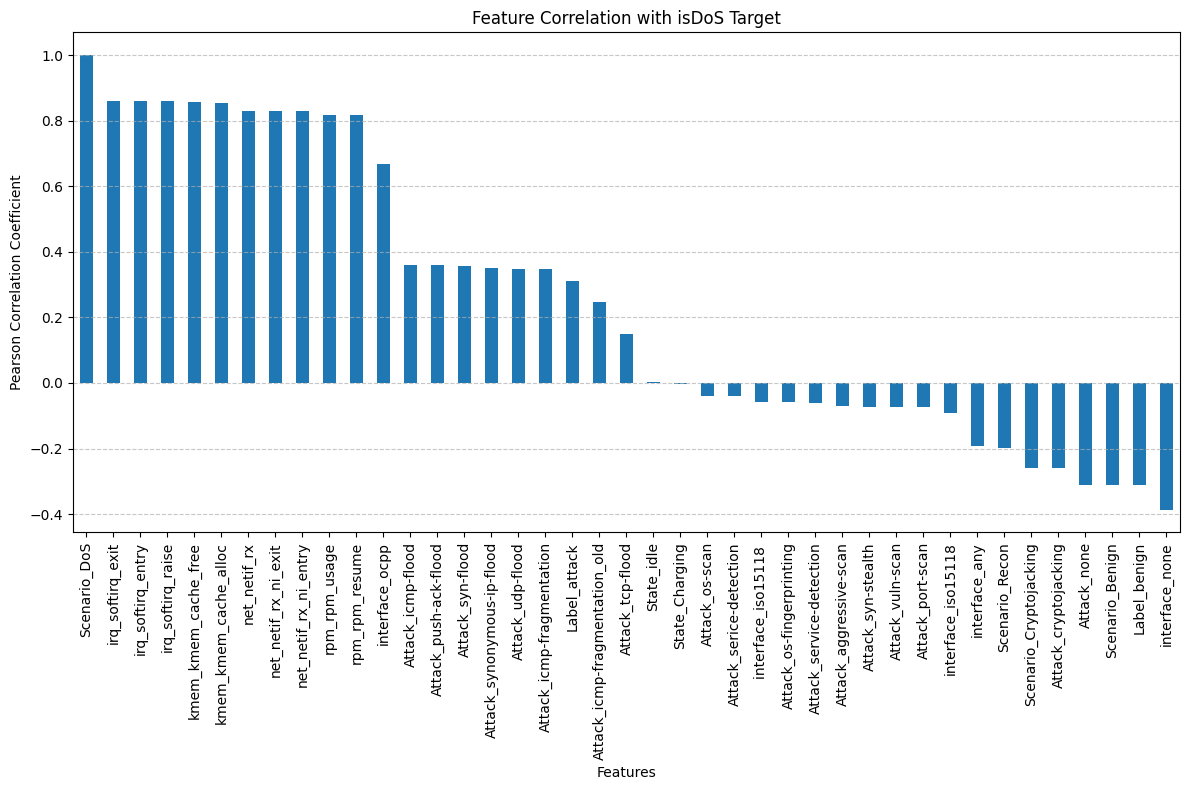

In [ ]:
import matplotlib.pyplot as plt

# 1. Concatenate the features DataFrame X and the target Series y into a single DataFrame.
combined_df = pd.concat([X, y], axis=1)

# 2. Calculate the Pearson correlation of all columns in this combined DataFrame with the 'isDoS' target variable.
correlation_with_isDoS = combined_df.corr()['isDoS']

# 3. Drop the 'isDoS' entry from this correlation series.
correlation_with_isDoS = correlation_with_isDoS.drop('isDoS')

# 4. Create a bar plot of these correlations.
plt.figure(figsize=(12, 8))
correlation_with_isDoS.sort_values(ascending=False).plot(kind='bar')

# 5. Add a title to the plot.
plt.title('Feature Correlation with isDoS Target')

# 6. Label the x-axis as 'Features' and the y-axis as 'Pearson Correlation Coefficient'.
plt.xlabel('Features')
plt.ylabel('Pearson Correlation Coefficient')

# 7. Rotate x-axis labels if necessary for better readability.
plt.xticks(rotation=90)

# 8. Display the plot.
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()